In [1]:
!pip install missingno

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/duyem54/43-temp/data_43_temp.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/duyem54/43-temp/data_43_temp.csv", skiprows=[1,2]) #trước mắt bỏ 2 dòng đầu cho dễ xử lí
# df = pd.read_csv("/kaggle/input/datasets/anhduy54/43-wind/Data_WindSpeed_43.csv")
print(f"temp_dataset: {df.shape}")

temp_dataset: (17526, 44)


In [4]:
# df.isna().sum()

---
# **Create Missing Data**

In [5]:
# ===== Missing data generation: random gap lengths per column =====
def generate_reproducible_gaps(df_input, gap_days_choices=None, num_gaps=10, seed=42, rows_per_day=8):
    """
    Phương pháp mới: locate daily start indices bằng cột TimeVN (hour == 1:00),
    sau đó random assign gap starts và lengths cho từng column.
    gap_days_choices: danh sách độ dài gap (ngày) — random chọn ngẫu nhiên mỗi gap.
    """
    if gap_days_choices is None:
        gap_days_choices = [1, 3, 5, 7]

    df_temp = df_input.copy(deep=True)
    feature_columns = [col for col in df_temp.columns if col != "TimeVN"]

    # Locate daily start indices từ TimeVN (hour == 1)
    ts = pd.to_datetime(df_temp['TimeVN'], format='mixed', dayfirst=True, errors='coerce')
    daily_start_indices = df_temp.index[ts.dt.hour == 1].tolist()

    np.random.seed(seed)

    max_gap_rows = max(gap_days_choices) * rows_per_day

    for col in feature_columns:
        valid_starts = [idx for idx in daily_start_indices
                        if idx + max_gap_rows <= len(df_temp)]

        if not valid_starts:
            # Fallback: index-based nếu không tìm được daily indices
            max_valid_start_idx = max(0, len(df_temp) - max_gap_rows)
            start_indices = np.random.randint(0, max_valid_start_idx, size=num_gaps)
            gap_days = np.random.choice(gap_days_choices, size=num_gaps)
            for start_idx, days in zip(start_indices, gap_days):
                gap_length = days * rows_per_day
                df_temp.loc[start_idx: start_idx + gap_length - 1, col] = np.nan
        else:
            chosen_starts = np.random.choice(valid_starts, size=num_gaps, replace=True)
            gap_days = np.random.choice(gap_days_choices, size=num_gaps)
            for start_idx, days in zip(chosen_starts, gap_days):
                end_idx = start_idx + days * rows_per_day
                df_temp.loc[start_idx: end_idx - 1, col] = np.nan

    return df_temp


# ===== Tạo 1 bộ missing data với gap ngẫu nhiên từ [1, 3, 5, 7] ngày =====
df_missing = generate_reproducible_gaps(
    df,
    gap_days_choices=[1, 3, 5, 7],
    num_gaps=10,
    seed=42
)

total_nan = df_missing.isna().sum().sum()
print(f"\nTạo missing dataset hoàn tất!")
print(f"Tổng số NaN: {total_nan}")
for col in df_missing.columns[1:]:
    n = df_missing[col].isna().sum()
    if n > 0:
        print(f"  {col}: {n} missing values")


Tạo missing dataset hoàn tất!
Tổng số NaN: 13960
  48805: 384 missing values
  48808: 416 missing values
  48803: 416 missing values
  48800: 400 missing values
  48830: 368 missing values
  48812: 352 missing values
  48838: 336 missing values
  48811: 240 missing values
  48837: 224 missing values
  48806: 368 missing values
  48833: 256 missing values
  48825: 352 missing values
  48818: 352 missing values
  48826: 288 missing values
  48823: 320 missing values
  48842: 432 missing values
  48839: 272 missing values
  48840: 304 missing values
  48845: 384 missing values
  48846: 320 missing values
  48/86: 208 missing values
  48848: 432 missing values
  48860: 272 missing values
  48852: 320 missing values
  48855: 352 missing values
  48863: 424 missing values
  48/96: 280 missing values
  48866: 352 missing values
  48870: 352 missing values
  48873: 272 missing values
  48875: 224 missing values
  48877: 400 missing values
  48890: 320 missing values
  48887: 272 missing value

<Axes: >

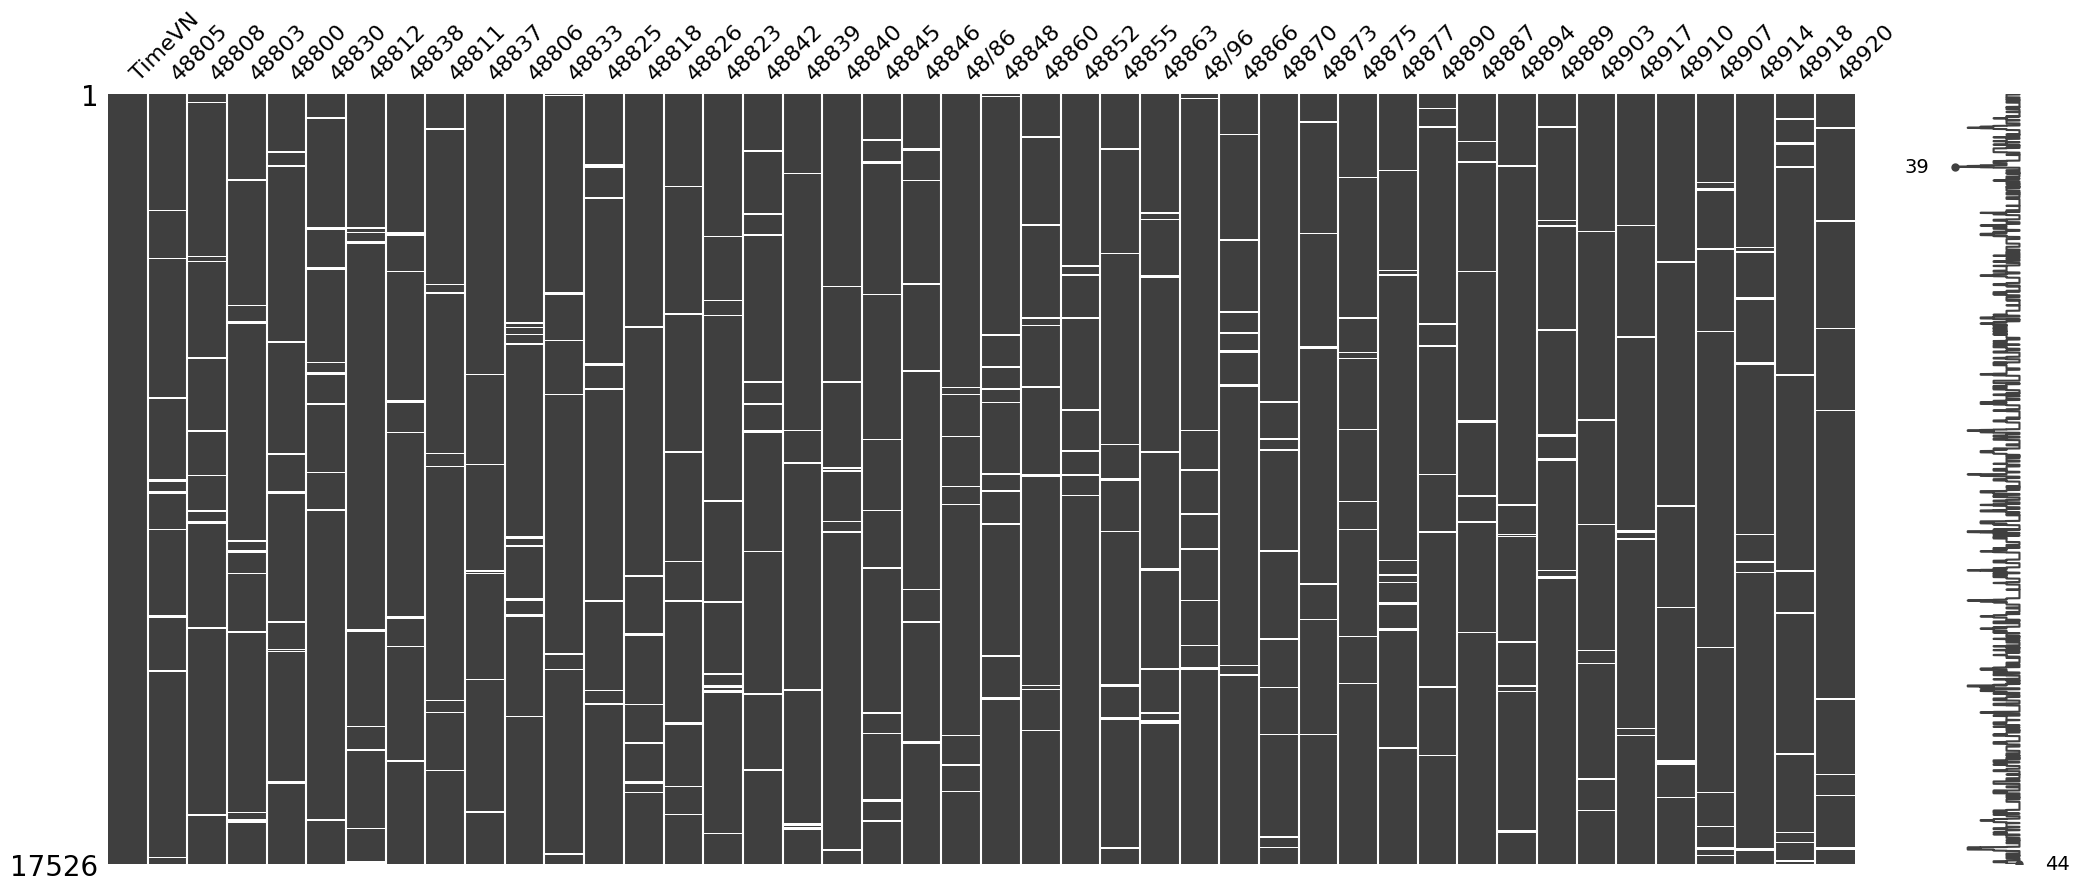

In [6]:
# print(f'df_3: {df_3.isnull().sum().sum()}') 
# print(f'df_5: {df_5.isnull().sum().sum()}') 
# print(f'df_7: {df_7.isnull().sum().sum()}') 
# print(f'df_10: {df_10.isnull().sum().sum()}') 
# print(f'df_15: {df_15.isnull().sum().sum()}') 
# print(f'df_30: {df_30.isnull().sum().sum()}') 

import missingno as msno
msno.matrix(df_missing)

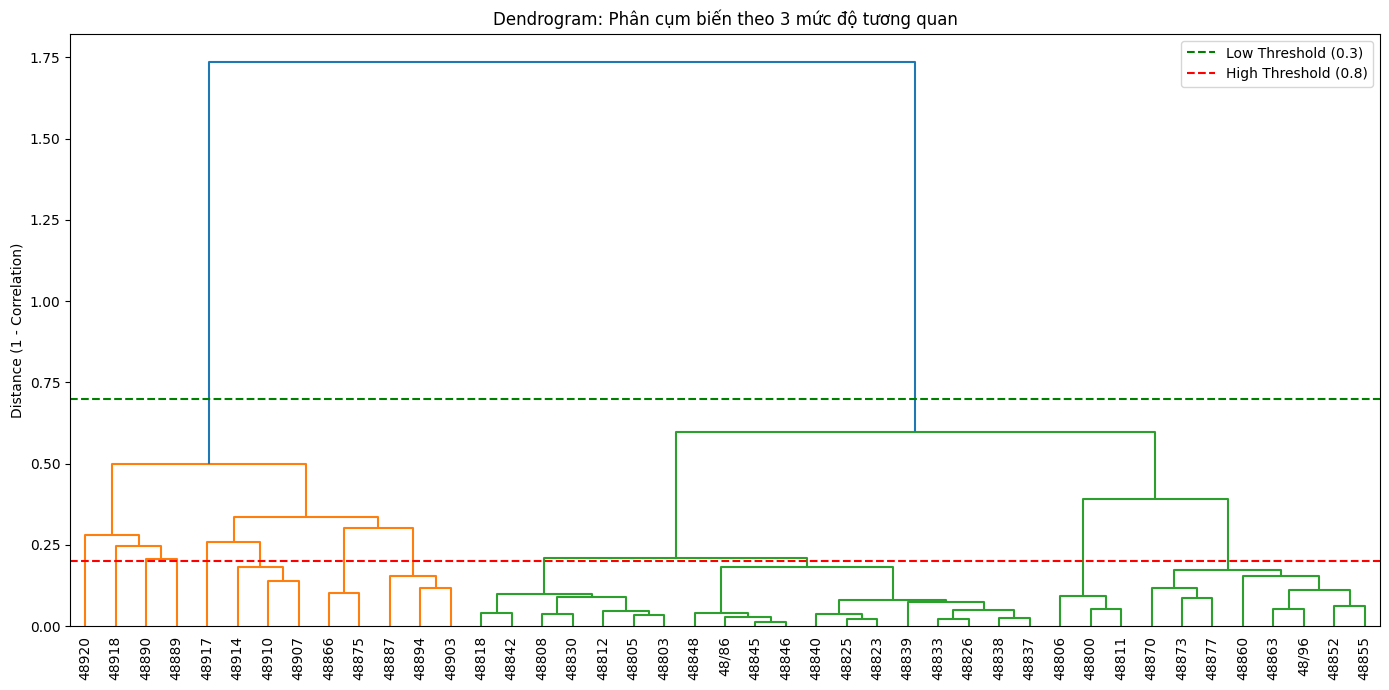

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

def split_by_hierarchical_correlation(df, low_thresh, high_thresh, time_col='TimeVN'):
    # Tách dữ liệu số để tính toán
    df_numeric = df.select_dtypes(include=[np.number])
    
    # 1. Ensemble Correlation
    corr = (df_numeric.corr(method='pearson').abs() + 
            df_numeric.corr(method='spearman').abs()) / 2
    
    # 2. Distance Matrix & Linkage (Dùng cho Dendrogram)
    dist_matrix = 1 - corr.fillna(0)
    dist_vec = squareform(dist_matrix, checks=False)
    linkage_matrix = hierarchy.ward(dist_vec)
    
    # 3. Tính Degree Centrality (Mức độ quan trọng trung bình của biến trong mạng lưới)
    global_scores = (corr.sum() - 1) / (len(corr) - 1)
    
    # 4. Phân tách theo 3 ngưỡng
    # Low: score < 0.3
    low_cols = global_scores[global_scores < low_thresh].index.tolist()
    # Medium: 0.3 <= score < 0.8
    med_cols = global_scores[(global_scores >= low_thresh) & (global_scores < high_thresh)].index.tolist()
    # High: score >= 0.8
    high_cols = global_scores[global_scores >= high_thresh].index.tolist()
    
    # 5. Trả kết quả (Kèm theo cột thời gian nếu có)
    time_list = [time_col] if time_col in df.columns else []
    
    df_low = df[time_list + low_cols]
    df_med = df[time_list + med_cols]
    df_high = df[time_list + high_cols]
    
    return df_low, df_med, df_high, global_scores, linkage_matrix

# --- Thực thi ---
df_low, df_med, df_high, scores, linkage = split_by_hierarchical_correlation(df_missing, low_thresh=0.6, high_thresh=0.75)

# --- Trực quan hóa ---
plt.figure(figsize=(14, 7))
dendro = hierarchy.dendrogram(linkage, labels=scores.index, leaf_rotation=90, leaf_font_size=10)

# Vẽ các đường ngưỡng (Chú ý: Dendrogram dùng khoảng cách d = 1 - correlation)
plt.axhline(y=1-0.3, color='green', linestyle='--', label='Low Threshold (0.3)')
plt.axhline(y=1-0.8, color='red', linestyle='--', label='High Threshold (0.8)')

plt.title("Dendrogram: Phân cụm biến theo 3 mức độ tương quan")
plt.ylabel("Distance (1 - Correlation)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# --- Thống kê số lượng ---
# Trừ đi 1 nếu có cột TimeVN trong DataFrame
def count_features(df, has_time=True):
    return df.shape[1] - 1 if has_time else df.shape[1]

n_low = count_features(df_low)
n_med = count_features(df_med)
n_high = count_features(df_high)
total = n_low + n_med + n_high

print("=== THỐNG KÊ FEATURE THEO NHÓM ===")
print(f"🔹 Nhóm Low (Score < 0.6):   {n_low} features")
print(f"🔸 Nhóm Med (0.6 - 0.75):    {n_med} features")
print(f"🚀 Nhóm High (Score >= 0.75): {n_high} features")
print(f"Tổng cộng: {total} features")

=== THỐNG KÊ FEATURE THEO NHÓM ===
🔹 Nhóm Low (Score < 0.6):   4 features
🔸 Nhóm Med (0.6 - 0.75):    14 features
🚀 Nhóm High (Score >= 0.75): 25 features
Tổng cộng: 43 features


---
# **Models : MLP(spatial) + Embedding(temporal) + LSTM/GRU**

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error
from torch.utils.data import TensorDataset, DataLoader

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sử dụng thiết bị: {device}")

# Đảm bảo df_missing ban đầu có Index là thời gian
df_missing.index = pd.to_datetime(df_missing.index)

# Chạy lại hàm chia nhóm của bạn
df_low, df_med, df_high, scores, linkage = split_by_hierarchical_correlation(df_missing, low_thresh=0.6, high_thresh=0.75)

# FIX: Ép kiểu Index cho các nhóm về Datetime để lấy được .hour, .dayofweek
for d in [df_low, df_med, df_high]:
    d.index = pd.to_datetime(df_missing.index)

Sử dụng thiết bị: cuda


In [10]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import warnings
import gc
import os
from tqdm.auto import tqdm

# ==========================================
# 0. CẤU HÌNH HỆ THỐNG GPU (OPTIMIZED)
# ==========================================
warnings.filterwarnings("ignore")
torch.set_printoptions(precision=4, sci_mode=False)
MODEL_DIR = 'saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Kích hoạt GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True 
print(f"🚀 Đang thực thi trên: {device}")

# ==========================================
# 1. TIỀN XỬ LÝ (LINEAR SEED)
# ==========================================
def get_simple_seed(df_miss):
    df_num = df_miss.select_dtypes(include=[np.number]).copy().astype('float32')
    df_num = df_num.interpolate(method='linear', limit_direction='both')
    return df_num.ffill().bfill().fillna(0)

# ==========================================
# 2. KIẾN TRÚC DEEP LEARNING (BI-GRU)
# ==========================================
class SingleStationImputer(nn.Module):
    def __init__(self, num_features, window_size=12, hidden_units=64):
        super().__init__()
        self.window_size = window_size
        self.gru = nn.GRU(num_features, hidden_units, num_layers=1, 
                          batch_first=True, bidirectional=True)
        self.h_emb = nn.Embedding(24, 8)
        self.d_emb = nn.Embedding(7, 4)
        self.m_emb = nn.Embedding(12, 6)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_units * 2 + 18, hidden_units),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_units, hidden_units // 2),
            nn.ReLU(),
            nn.Linear(hidden_units // 2, 1) 
        )

    def forward(self, x, t_feat):
        out, _ = self.gru(x)
        gru_ctx = out[:, out.shape[1]//2, :] 
        h, d, m = self.h_emb(t_feat[:,0]), self.d_emb(t_feat[:,1]), self.m_emb(t_feat[:,2])
        return self.mlp(torch.cat([gru_ctx, h, d, m], dim=-1))

# ==========================================
# 3. CORE: CHẠY DL (TRAIN HOẶC LOAD MODEL TỔNG)
# ==========================================
def run_hybrid_imputation_group(df_miss_group, df_seed_all, group_name, epochs=30, W=8, force_train=False):
    df_num = df_miss_group.select_dtypes(include=[np.number]).astype('float32')
    target_cols = df_num.columns.tolist()
    working = df_seed_all[target_cols].copy().astype('float32')
    times = pd.to_datetime(df_miss_group.index)
    T_all = np.array([[t.hour, t.dayofweek, t.month - 1] for t in times])
    
    model_path = os.path.join(MODEL_DIR, f"models_{group_name}_total.pth")
    group_model_states = {}
    
    load_mode = os.path.exists(model_path) and not force_train
    if load_mode:
        print(f"📦 Đã tìm thấy file model tổng cho nhóm {group_name}. Đang tiến hành Load...")
        group_model_states = torch.load(model_path, map_location=device)

    pbar = tqdm(target_cols, desc=f"Processing {group_name}")
    for target in pbar:
        miss_mask = df_num[target].isna().values
        if not miss_mask.any(): continue
        
        pred_cols = [c for c in target_cols if c != target]
        scaler_X, scaler_Y = StandardScaler(), StandardScaler()
        data_X_sc = scaler_X.fit_transform(working[pred_cols].values)
        data_Y_sc = scaler_Y.fit_transform(working[target].values.reshape(-1, 1)).flatten()

        n_rows = len(data_X_sc)
        X_seq = np.zeros((n_rows, W*2+1, len(pred_cols)), dtype='float32')
        for i in range(n_rows):
            start, end = max(0, i - W), min(n_rows, i + W + 1)
            chunk = data_X_sc[start:end]
            if len(chunk) < W*2+1:
                pad_val = chunk[0:1] if i < W else chunk[-1:]
                pad = np.repeat(pad_val, (W*2+1)-len(chunk), axis=0)
                chunk = np.vstack([pad, chunk]) if i < W else np.vstack([chunk, pad])
            X_seq[i] = chunk

        model = SingleStationImputer(len(pred_cols), W).to(device)
        
        if load_mode and target in group_model_states:
            model.load_state_dict(group_model_states[target])
        else:
            X_train = torch.from_numpy(X_seq[~miss_mask])
            Y_train = torch.from_numpy(data_Y_sc[~miss_mask])
            T_train = torch.from_numpy(T_all[~miss_mask]).long()
            
            loader = DataLoader(TensorDataset(X_train, T_train, Y_train), 
                                batch_size=32, shuffle=True, pin_memory=True)
            optimizer = optim.Adam(model.parameters(), lr=0.001)
            criterion = nn.MSELoss()
            
            model.train()
            for _ in range(epochs):
                for bx, bt, by in loader:
                    bx, bt, by = bx.to(device, non_blocking=True), bt.to(device, non_blocking=True), by.to(device, non_blocking=True)
                    optimizer.zero_grad()
                    criterion(model(bx, bt).squeeze(), by).backward()
                    optimizer.step()
            
            group_model_states[target] = {k: v.cpu() for k, v in model.state_dict().items()}

        model.eval()
        X_test = torch.from_numpy(X_seq[miss_mask]).to(device)
        T_test = torch.from_numpy(T_all[miss_mask]).long().to(device)
        with torch.no_grad():
            test_loader = DataLoader(TensorDataset(X_test, T_test), batch_size=128)
            y_preds = np.concatenate([model(bx, bt).cpu().numpy() for bx, bt in test_loader])
        
        working.loc[miss_mask, target] = scaler_Y.inverse_transform(y_preds.reshape(-1, 1)).flatten()
        del X_seq, model; gc.collect(); torch.cuda.empty_cache()

    if not load_mode:
        torch.save(group_model_states, model_path)
        print(f"💾 Đã lưu model tổng cho {group_name}")
        
    return working

# ==========================================
# 4. MACHINE LEARNING BASELINES
# ==========================================
def run_ml_imputation(df_miss, df_seed, method='RF'):
    df_num = df_miss.select_dtypes(include=[np.number]).astype('float32')
    target_cols, working = df_num.columns.tolist(), df_seed[df_num.columns].copy()
    
    for target in tqdm(target_cols, desc=f"ML {method}"):
        m_idx = df_num[target].isna()
        if not m_idx.any(): continue
        pred_cols = [c for c in target_cols if c != target]
        model = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42) if method == 'RF' else XGBRegressor(n_estimators=50, n_jobs=-1, random_state=42, verbosity=0)
        model.fit(working.loc[~m_idx, pred_cols], working.loc[~m_idx, target])
        working.loc[m_idx, target] = model.predict(working.loc[m_idx, pred_cols])
    return working

# ==========================================
# 5. FULL METRICS (NSE, R2, Sim, RMSE, MAE, NMAE, FB)
# ==========================================
def get_final_metrics(df_orig, df_imp, df_miss):
    stats = []
    common_cols = [c for c in df_miss.columns if c in df_orig.columns and c in df_imp.columns and c not in ['TimeVN', 'Time', 'Date']]
    
    for col in common_cols:
        mask = pd.isna(df_miss[col].values) & ~pd.isna(df_orig[col].values)
        yt, yp = df_orig[col].values[mask], df_imp[col].values[mask]
        valid = ~np.isnan(yp); yt, yp = yt[valid], yp[valid]
        if len(yt) < 2: continue
            
        T = len(yt)
        v_min, v_max = np.nanmin(df_orig[col].values), np.nanmax(df_orig[col].values)
        rng = v_max - v_min if v_max > v_min else 1.0
        
        rmse = np.sqrt(np.mean((yt - yp)**2))
        mae = np.mean(np.abs(yp - yt))
        sim = (1/T) * np.sum(1 / (1 + (np.abs(yp - yt) / rng)))
        nmae = mae / rng
        fb = 2 * np.mean(yp - yt) / (np.mean(yp) + np.mean(yt) + 1e-9)
        
        nse = 1 - (np.sum((yt - yp)**2) / (np.sum((yt - np.mean(yt))**2) + 1e-9))
        r2 = r2_score(yt, yp)
        
        stats.append({
            "Station": col, "NSE": nse, "R2": r2, "Sim": sim,
            "RMSE": rmse, "MAE": mae, "NMAE": nmae, "FB": fb
        })
    return pd.DataFrame(stats)

# ==========================================
# 6. EXECUTION & RESTRUCTURED DISPLAY
# ==========================================
# Đảm bảo bạn đã có df_missing, df, df_low, df_med, df_high trước khi chạy đoạn này
df_seed = get_simple_seed(df_missing)

# Chạy ML Baselines
ml_results = {m: run_ml_imputation(df_missing, df_seed, method=m) for m in ['RF', 'XGB']}

comparison_data = []
groups = [('LOW', df_low), ('MED', df_med), ('HIGH', df_high)]

for label, df_m_group in groups:
    res_dl = run_hybrid_imputation_group(df_m_group, df_seed, label, epochs=30, W=8)
    
    all_imputed_results = {'DL_BiGRU': res_dl, 'RF': ml_results['RF'], 'XGBoost': ml_results['XGB']}
    
    for model_name, df_imp in all_imputed_results.items():
        metrics_df = get_final_metrics(df, df_imp, df_m_group)
        s = metrics_df.mean(numeric_only=True)
        comparison_data.append({
            'Model': model_name, 'Level': label, 
            'NSE (↑)': s['NSE'], 'R2 (↑)': s['R2'], 'Sim (↑)': s['Sim'],
            'RMSE (↓)': s['RMSE'], 'MAE (↓)': s['MAE'], 'NMAE (↓)': s['NMAE'], 'FB (→0)': s['FB']
        })
    del res_dl; gc.collect(); torch.cuda.empty_cache()

# Tạo DataFrame và sắp xếp lại theo cụm Model
final_df = pd.DataFrame(comparison_data)
final_df['Level'] = pd.Categorical(final_df['Level'], categories=['LOW', 'MED', 'HIGH'], ordered=True)
final_df = final_df.sort_values(['Model', 'Level'])
styled_df = final_df.set_index(['Model', 'Level'])

# --- HIỂN THỊ ---
print("\n" + "="*50)
display(styled_df.style.format(precision=4)\
    .background_gradient(cmap='RdYlGn', subset=['NSE (↑)', 'R2 (↑)', 'Sim (↑)'])\
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE (↓)', 'MAE (↓)']))

🚀 Đang thực thi trên: cuda


ML RF:   0%|          | 0/43 [00:00<?, ?it/s]

ML XGB:   0%|          | 0/43 [00:00<?, ?it/s]

Processing LOW:   0%|          | 0/4 [00:00<?, ?it/s]

💾 Đã lưu model tổng cho LOW


Processing MED:   0%|          | 0/14 [00:00<?, ?it/s]

💾 Đã lưu model tổng cho MED


Processing HIGH:   0%|          | 0/25 [00:00<?, ?it/s]

💾 Đã lưu model tổng cho HIGH

